##1. Import Libraries

In [ ]:
# ------------------------------------------------------------
# 1. Import Libraries
# Purpose: Load required Python libraries for data analysis
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Improve display formatting for readability
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


#2. Load Dataset

In [ ]:
# ------------------------------------------------------------
# 2. Load Dataset
# Purpose: Read the retail transactional dataset
# ------------------------------------------------------------

df = pd.read_excel("Online Retail.xlsx", engine="openpyxl")

# Preview first few rows
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'Online Retail.xlsx'

#3. Initial Overview (Raw Data)

In [ ]:
# ------------------------------------------------------------
# 3. Raw Data Overview
# Purpose: Understand dataset structure before cleaning
# ------------------------------------------------------------

print("Shape:", df.shape)
print("Columns:", df.columns)
df.info()


Shape: (541909, 8)
Columns: Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


#4. Data Cleaning

4.1 Standardise Columns

In [ ]:
# ------------------------------------------------------------
# 4.1 Standardise Column Formats and Data Types
# Purpose: Ensure consistency and remove formatting issues
# ------------------------------------------------------------

df["InvoiceNo"] = df["InvoiceNo"].astype(str).str.strip()
df["StockCode"] = df["StockCode"].astype(str).str.strip()
df["Description"] = df["Description"].astype(str).str.strip()
df["Country"] = df["Country"].astype(str).str.strip()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")

# Identify cancelled transactions
df["is_cancelled"] = df["InvoiceNo"].str.startswith("C")


4.2 Create Gross and Net Datasets

In [ ]:
# ------------------------------------------------------------
# 4.2 Create Clean Analytical Datasets
# gross: includes all valid transactions
# net: excludes cancellations (used for KPIs)
# ------------------------------------------------------------

# Remove invalid dates, zero prices, and zero quantities
gross = df.dropna(subset=["InvoiceDate"]).copy()
gross = gross[(gross["UnitPrice"] > 0) & (gross["Quantity"] != 0)]

# Calculate gross revenue
gross["gross_revenue"] = gross["Quantity"] * gross["UnitPrice"]

# Create net dataset (exclude cancelled transactions)
net = gross[~gross["is_cancelled"]].copy()
net = net[net["Quantity"] > 0]

# Calculate net revenue
net["net_revenue"] = net["Quantity"] * net["UnitPrice"]

# Create time-based features
net["invoice_date"] = net["InvoiceDate"].dt.date
net["year_month"] = net["InvoiceDate"].dt.to_period("M").astype(str)

# Check shapes
(net.shape, gross.shape)


((530104, 13), (539392, 10))

5. Dataset Overview (Cleaned Data)

In [ ]:
# ------------------------------------------------------------
# 5. Dataset Overview (Net Dataset)
# Purpose: Summary statistics for report inclusion
# ------------------------------------------------------------

overview = {
    "rows": len(net),
    "columns": net.shape[1],
    "date_min": net["InvoiceDate"].min(),
    "date_max": net["InvoiceDate"].max(),
    "unique_invoices": net["InvoiceNo"].nunique(),
    "unique_customers": net["CustomerID"].nunique(),
    "unique_products": net["StockCode"].nunique(),
    "countries": net["Country"].nunique(),
}

overview


{'rows': 530104,
 'columns': 13,
 'date_min': Timestamp('2010-12-01 08:26:00'),
 'date_max': Timestamp('2011-12-09 12:50:00'),
 'unique_invoices': 19960,
 'unique_customers': 4338,
 'unique_products': 3922,
 'countries': 38}

#6. Missing Values Check

In [ ]:
# ------------------------------------------------------------
# 6. Missing Values Analysis
# ------------------------------------------------------------

net.isna().sum().sort_values(ascending=False).head(10)


,0
CustomerID,132220
StockCode,0
Description,0
Quantity,0
InvoiceNo,0
InvoiceDate,0
UnitPrice,0
Country,0
is_cancelled,0
gross_revenue,0


#7. Country Distribution

In [ ]:
# ------------------------------------------------------------
# 7. Top Countries by Transaction Volume
# ------------------------------------------------------------

net["Country"].value_counts().head(10)


,count
Country,
United Kingdom,485123
Germany,9040
France,8407
EIRE,7890
Spain,2484
Netherlands,2359
Belgium,2031
Switzerland,1966
Portugal,1501


#8. KPI Summary (Core Retail Metrics)

In [ ]:
# ------------------------------------------------------------
# 8. Key Performance Indicators (KPIs)
# ------------------------------------------------------------

kpis = pd.DataFrame([{
    "Total Revenue (£)": net["net_revenue"].sum(),
    "Total Orders": net["InvoiceNo"].nunique(),
    "Total Customers": net["CustomerID"].nunique(),
    "Total Units Sold": net["Quantity"].sum(),
    "Avg Order Value (£)": net.groupby("InvoiceNo")["net_revenue"].sum().mean()
}])

kpis


,Total Revenue (£),Total Orders,Total Customers,Total Units Sold,Avg Order Value (£)
0,10666684.54,19960,4338,5588376,534.40


#9. Monthly Revenue Trend

In [ ]:
# ------------------------------------------------------------
# 9. Monthly Revenue Analysis
# ------------------------------------------------------------

monthly_rev = (
    net.groupby("year_month")["net_revenue"]
    .sum()
    .reset_index()
    .sort_values("year_month")
)

monthly_rev.head(12)


,year_month,net_revenue
0,2010-12,823746.14
1,2011-01,691364.56
2,2011-02,523631.89
3,2011-03,717639.36
4,2011-04,537808.62
5,2011-05,770536.02
6,2011-06,761739.90
7,2011-07,719221.19
8,2011-08,759138.38
9,2011-09,1058590.17


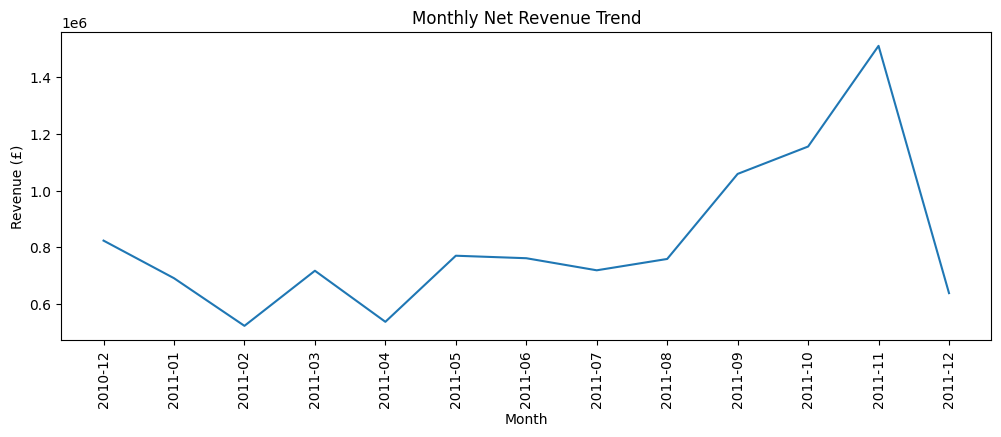

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(monthly_rev["year_month"], monthly_rev["net_revenue"])
plt.xticks(rotation=90)
plt.title("Monthly Net Revenue Trend")
plt.ylabel("Revenue (£)")
plt.xlabel("Month")
plt.show()


## 10. Product Analysis


Top 10 Products by Revenue

In [ ]:
top_products = (
    net
    .groupby("Description")["net_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products


,net_revenue
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174484.74
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106292.77
PARTY BUNTING,99504.33
JUMBO BAG RED RETROSPOT,94340.05
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
Manual,78112.82
POSTAGE,78101.88


Product Revenue Distribution (Long-tail Effect)

In [ ]:
product_revenue = (
    net
    .groupby("Description")["net_revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.describe()


,net_revenue
count,4015.00
mean,2656.71
std,7826.73
min,0.00
25%,126.77
50%,671.01
75%,2201.61
max,206248.77


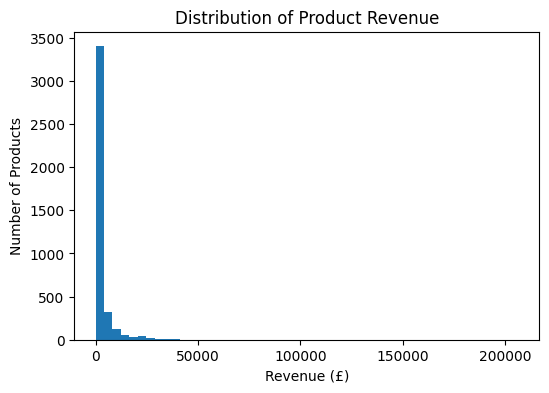

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(product_revenue, bins=50)
plt.title("Distribution of Product Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Products")
plt.show()


## 11. Customer Behaviour


Orders per Customer

In [ ]:
orders_per_customer = net.groupby("CustomerID")["InvoiceNo"].nunique()

orders_per_customer.describe()


,InvoiceNo
count,4338.00
mean,4.27
std,7.70
min,1.00
25%,1.00
50%,2.00
75%,5.00
max,209.00


Revenue per Customer

In [ ]:
revenue_per_customer = net.groupby("CustomerID")["net_revenue"].sum()

revenue_per_customer.describe()

,net_revenue
count,4338.00
mean,2054.27
std,8989.23
min,3.75
25%,307.41
50%,674.49
75%,1661.74
max,280206.02


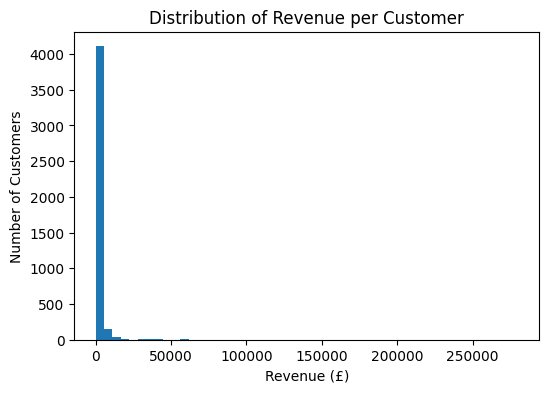

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(revenue_per_customer, bins=50)
plt.title("Distribution of Revenue per Customer")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Customers")
plt.show()


## 12. Geographic Analysis


Revenue by Country

In [ ]:
country_revenue = (
    net
    .groupby("Country")["net_revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)


,net_revenue
Country,
United Kingdom,9025222.08
Netherlands,285446.34
EIRE,283453.96
Germany,228867.14
France,209715.11
Australia,138521.31
Spain,61577.11
Switzerland,57089.90
Belgium,41196.34


UK vs Non-UK Revenue Split

In [ ]:
net["is_uk"] = net["Country"].eq("United Kingdom")

uk_split = net.groupby("is_uk")["net_revenue"].sum()
uk_split


,net_revenue
is_uk,
False,1641462.46
True,9025222.08


## 7. Key EDA Findings

- Sales show clear temporal variation across months.
- Revenue is highly concentrated in a small number of products.
- Customer purchasing behaviour follows a long-tail pattern, with many one-time buyers.
- The United Kingdom dominates overall revenue contribution.
